# Overfitting, Underfitting & Noise: A Visual Guide

**Goal**: Understand model complexity through side-by-side visualizations

**Key Concepts**:
- **Underfitting**: Model too simple → High E_train, High E_test
- **Overfitting**: Model too complex → Low E_train, High E_test  
- **Good Fit**: Balanced complexity → Low E_train, Low E_test


## Regression can sometimes capture completely false information!

Left slope  =  0.0993132778612
Right slope = -2.79521777083e-17


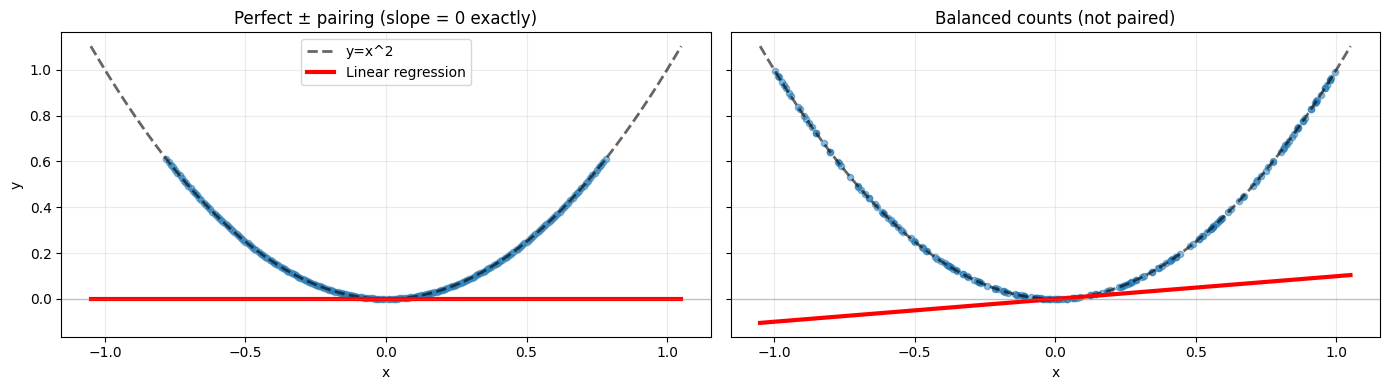

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Two panels: (left) balanced counts but NOT paired -> slope ~ 0, (right) perfectly paired -> slope = 0 exactly
rng = np.random.default_rng(0)
N_half = 100

# LEFT: same number of points on each side, but x's are independent -> not exact cancellation
x_left = np.r_[rng.uniform(-1, 0, N_half), rng.uniform(0, 1, N_half)]
y_left = x_left**2

# RIGHT: perfectly paired +/-x using dyadic fractions (multiples of 1/128) -> exact cancellation in float64
den = 128  # power of 2 => exactly representable
x_pos = np.arange(1, N_half + 1) / den
x_right = np.r_[-x_pos, x_pos]
y_right = x_right**2

# Linear regression forced through origin
lr_left  = LinearRegression(fit_intercept=False).fit(x_left.reshape(-1, 1),  y_left)
lr_right = LinearRegression(fit_intercept=False).fit(x_right.reshape(-1, 1), y_right)

print(f"Left slope  = {lr_left.coef_[0]: .12g}")
print(f"Right slope = {lr_right.coef_[0]: .12g}")

x_plot = np.linspace(-1.05, 1.05, 400).reshape(-1, 1)

fig, ax = plt.subplots(1, 2, figsize=(14, 4), sharex=True, sharey=True)


ax[0].scatter(x_right, y_right, s=20, alpha=0.5)
ax[0].plot(x_plot, x_plot[:, 0]**2, "k--", lw=2, alpha=0.6, label="y=x^2")
ax[0].plot(x_plot, lr_right.predict(x_plot), "r", lw=3, label="Linear regression")
ax[0].set_title("Perfect ± pairing (slope = 0 exactly)")

ax[1].scatter(x_left, y_left, s=20, alpha=0.5)
ax[1].plot(x_plot, x_plot[:, 0]**2, "k--", lw=2, alpha=0.6, label="y=x^2")
ax[1].plot(x_plot, lr_left.predict(x_plot), "r", lw=3, label="Linear regression")
ax[1].set_title("Balanced counts (not paired)")


for a in ax:
    a.axhline(0, color="gray", lw=1, alpha=0.4)
    a.grid(True, alpha=0.25)
    a.set_xlabel("x")
ax[0].set_ylabel("y")
ax[0].legend()

plt.tight_layout()
plt.show()


## Setup

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

%matplotlib inline
plt.rcParams['figure.figsize'] = (16, 5)
np.random.seed(42)
print('✓ Ready')

✓ Ready


## Core Functions (Run Once)

In [35]:
def generate_data(N, sigma, func_type='linear', x_max=1.0):
    """Generate training or test data"""
    x = x_max * np.random.random(N)
    noise = sigma * np.random.randn(N)
    
    if func_type == 'linear':
        y = 2 * x + noise
    else:  # complex
        y = 2*x - 10*x**5 + 15*x**10 + noise
    
    return x, y

def train_models(x_train, y_train):
    """Train 3 models: Order 1, 3, 10"""
    X = x_train.reshape(-1, 1)
    
    # Linear
    model_1 = LinearRegression().fit(X, y_train)
    
    # Order 3
    poly_3 = PolynomialFeatures(3)
    X_3 = poly_3.fit_transform(X)
    model_3 = LinearRegression().fit(X_3, y_train)
    
    # Order 10
    poly_10 = PolynomialFeatures(10)
    X_10 = poly_10.fit_transform(X)
    model_10 = LinearRegression().fit(X_10, y_train)
    
    return model_1, model_3, model_10, poly_3, poly_10

def plot_comparison(x_train, y_train, x_test, y_test, model_1, model_3, model_10, 
                   poly_3, poly_10, title, x_max=1.2):
    """Create side-by-side: Training Fit | Test Predictions"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    # Smooth curve for plotting
    x_plot = np.linspace(0, x_max, 300).reshape(-1, 1)
    X_plot_3 = poly_3.transform(x_plot)
    X_plot_10 = poly_10.transform(x_plot)
    
    y_pred_1 = model_1.predict(x_plot)
    y_pred_3 = model_3.predict(X_plot_3)
    y_pred_10 = model_10.predict(X_plot_10)
    
    # LEFT: Training fit
    ax1.scatter(x_train, y_train, s=150, c='black', alpha=0.6, edgecolors='white', linewidths=2, zorder=5)
    ax1.plot(x_plot, y_pred_1, 'r-', linewidth=3, label='Order 1 (Linear)', alpha=0.8)
    ax1.plot(x_plot, y_pred_3, 'orange', linewidth=3, label='Order 3', alpha=0.8)
    ax1.plot(x_plot, y_pred_10, 'g-', linewidth=3, label='Order 10', alpha=0.8)
    ax1.set_xlim(0, 1)
    ax1.set_ylim(-6, 12)
    ax1.set_xlabel('x', fontsize=14)
    ax1.set_ylabel('y', fontsize=14)
    ax1.set_title('TRAINING FIT', fontsize=16, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # RIGHT: Test predictions
    ax2.scatter(x_test, y_test, s=80, c='blue', alpha=0.4, label='Test Data', zorder=3)
    ax2.plot(x_plot, y_pred_1, 'r-', linewidth=3, label='Order 1 (Linear)', alpha=0.8)
    ax2.plot(x_plot, y_pred_3, 'orange', linewidth=3, label='Order 3', alpha=0.8)
    ax2.plot(x_plot, y_pred_10, 'g-', linewidth=3, label='Order 10', alpha=0.8)
    ax2.axvline(x=1.0, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Training Range')
    ax2.set_xlim(0, x_max)
    ax2.set_ylim(-6, 12)
    ax2.set_xlabel('x', fontsize=14)
    ax2.set_ylabel('y', fontsize=14)
    ax2.set_title('TEST PREDICTIONS', fontsize=16, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    
    fig.suptitle(title, fontsize=18, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

def compute_errors(x_train, y_train, x_test, y_test, model_1, model_3, model_10, poly_3, poly_10):
    """Compute and display E_train vs E_test"""
    X_train = x_train.reshape(-1, 1)
    X_test = x_test.reshape(-1, 1)
    
    # Training errors
    e_train_1 = mean_squared_error(y_train, model_1.predict(X_train))
    e_train_3 = mean_squared_error(y_train, model_3.predict(poly_3.transform(X_train)))
    e_train_10 = mean_squared_error(y_train, model_10.predict(poly_10.transform(X_train)))
    
    # Test errors
    e_test_1 = mean_squared_error(y_test, model_1.predict(X_test))
    e_test_3 = mean_squared_error(y_test, model_3.predict(poly_3.transform(X_test)))
    e_test_10 = mean_squared_error(y_test, model_10.predict(poly_10.transform(X_test)))
    
    print(f"{'Model':<15} {'E_train':>12} {'E_test':>12} {'Gap':>12}")
    print("-" * 55)
    print(f"{'Order 1':<15} {e_train_1:>12.4f} {e_test_1:>12.4f} {e_test_1-e_train_1:>12.4f}")
    print(f"{'Order 3':<15} {e_train_3:>12.4f} {e_test_3:>12.4f} {e_test_3-e_train_3:>12.4f}")
    print(f"{'Order 10':<15} {e_train_10:>12.4f} {e_test_10:>12.4f} {e_test_10-e_train_10:>12.4f}")
    
    # Find best
    best_idx = np.argmin([e_test_1, e_test_3, e_test_10])
    best_name = ['Order 1', 'Order 3', 'Order 10'][best_idx]
    print(f"\n✓ Best model (lowest E_test): {best_name}")

print('✓ Functions loaded')

✓ Functions loaded


---
## Experiment 1: Noiseless Data (M=10, σ=0, Linear)

**What to observe**: All models fit perfectly when there's no noise and enough parameters.


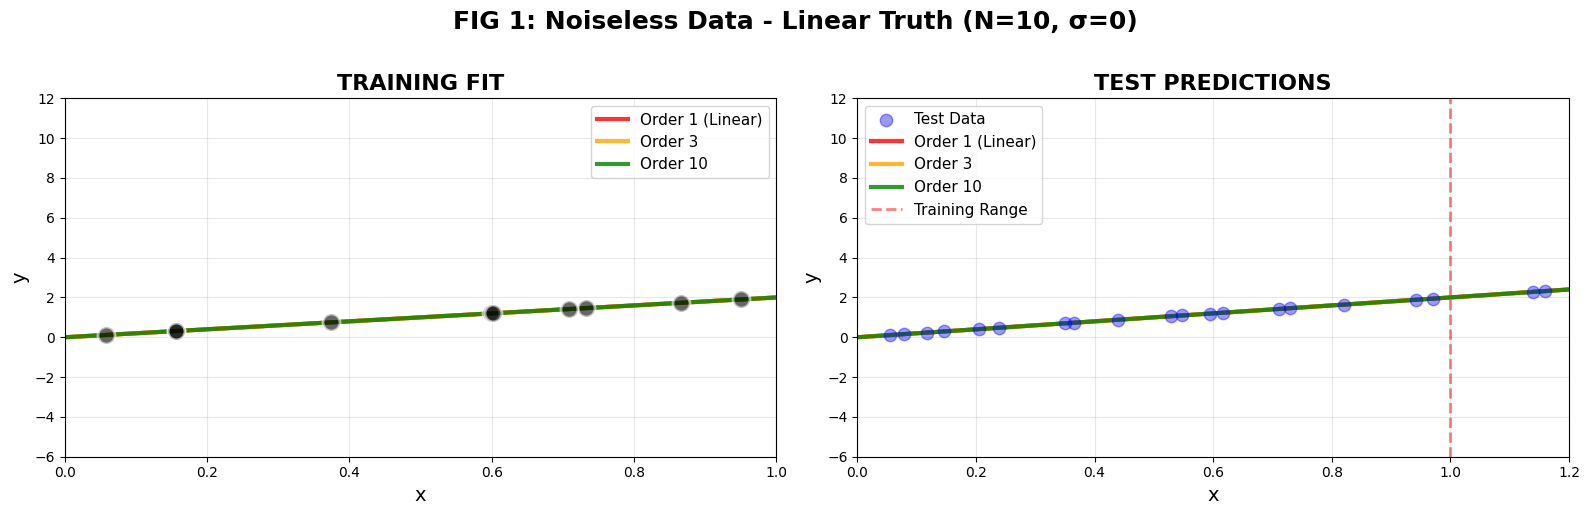

Model                E_train       E_test          Gap
-------------------------------------------------------
Order 1               0.0000       0.0000       0.0000
Order 3               0.0000       0.0000       0.0000
Order 10              0.0000       0.0000       0.0000

✓ Best model (lowest E_test): Order 3


In [36]:
# Generate data
x_train, y_train = generate_data(N=10, sigma=0.0, func_type='linear')
x_test, y_test = generate_data(N=20, sigma=0.0, func_type='linear', x_max=1.2)

# Train models
m1, m3, m10, p3, p10 = train_models(x_train, y_train)

# Visualize
plot_comparison(x_train, y_train, x_test, y_test, m1, m3, m10, p3, p10,
               'FIG 1: Noiseless Data - Linear Truth (N=10, σ=0)')

# Errors
compute_errors(x_train, y_train, x_test, y_test, m1, m3, m10, p3, p10)

---
## Experiment 2: Noiseless Data (M=10, σ=0, Complex)

**What to observe**: Simple models underfit complex truth. Order 10 fits perfectly.


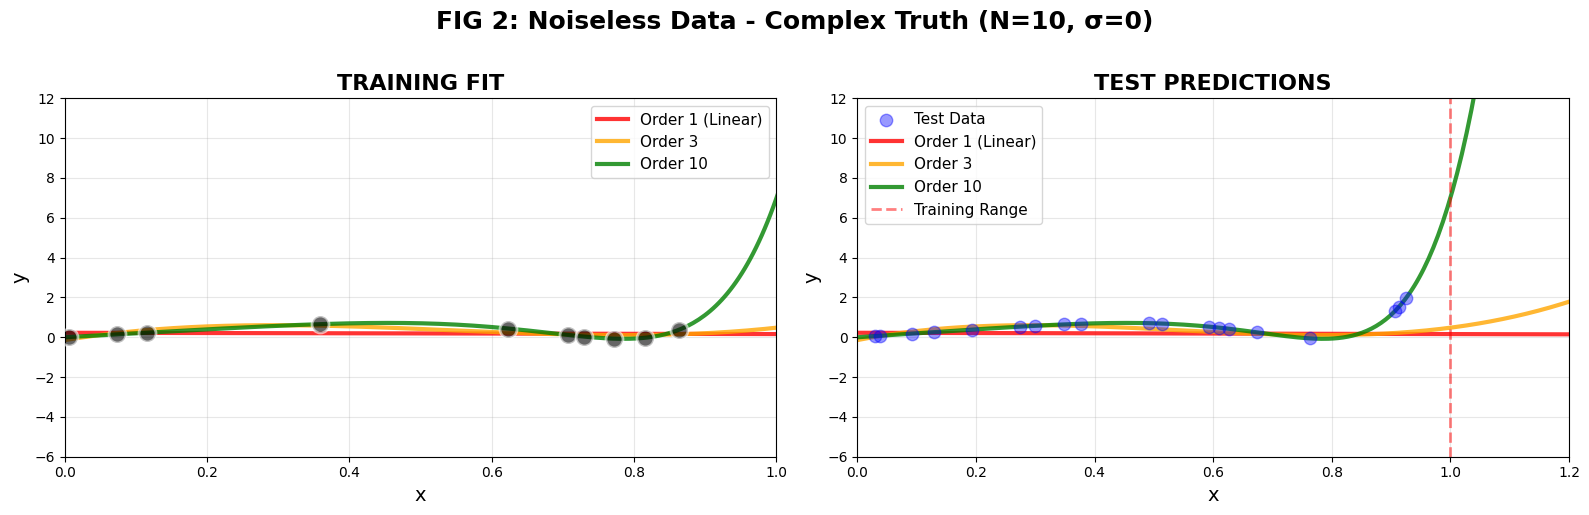

Model                E_train       E_test          Gap
-------------------------------------------------------
Order 1               0.0490      24.4108      24.3618
Order 3               0.0196      22.6706      22.6510
Order 10              0.0000       0.0000       0.0000

✓ Best model (lowest E_test): Order 10


In [37]:
# Generate data
x_train, y_train = generate_data(N=10, sigma=0.0, func_type='complex')
x_test, y_test = generate_data(N=20, sigma=0.0, func_type='complex', x_max=1.2)

# Train models
m1, m3, m10, p3, p10 = train_models(x_train, y_train)

# Visualize
plot_comparison(x_train, y_train, x_test, y_test, m1, m3, m10, p3, p10,
               'FIG 2: Noiseless Data - Complex Truth (N=10, σ=0)')

# Errors
compute_errors(x_train, y_train, x_test, y_test, m1, m3, m10, p3, p10)

---
## Experiment 3: Noisy Data - LINEAR TRUTH (M=100, σ=1)

**KEY OBSERVATION**: Order 10 OVERFITS! Low E_train but high E_test.

This is THE critical demonstration of overfitting.


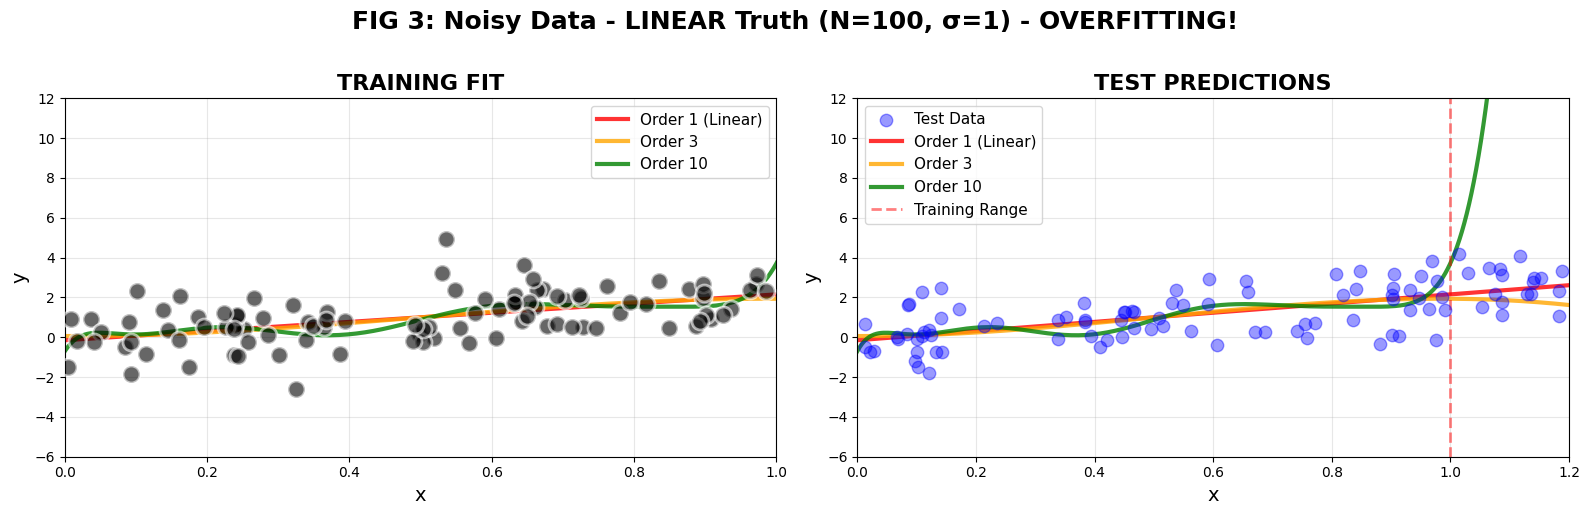


 CRITICAL: Notice Order 10 has low E_train but HIGH E_test (overfitting!)

Model                E_train       E_test          Gap
-------------------------------------------------------
Order 1               1.0891       1.0399      -0.0492
Order 3               1.0831       1.1466       0.0635
Order 10              1.0081     340.8855     339.8775

✓ Best model (lowest E_test): Order 1


In [38]:
# Generate data
x_train, y_train = generate_data(N=100, sigma=1.0, func_type='linear')
x_test, y_test = generate_data(N=100, sigma=1.0, func_type='linear', x_max=1.2)

# Train models
m1, m3, m10, p3, p10 = train_models(x_train, y_train)

# Visualize
plot_comparison(x_train, y_train, x_test, y_test, m1, m3, m10, p3, p10,
               'FIG 3: Noisy Data - LINEAR Truth (N=100, σ=1) - OVERFITTING!')

# Errors
print('\n CRITICAL: Notice Order 10 has low E_train but HIGH E_test (overfitting!)\n')
compute_errors(x_train, y_train, x_test, y_test, m1, m3, m10, p3, p10)

---
## Experiment 4: Noisy Data - COMPLEX TRUTH (M=100, σ=1)

**What to observe**: Even with complex truth, Order 10 struggles with noise and extrapolation.


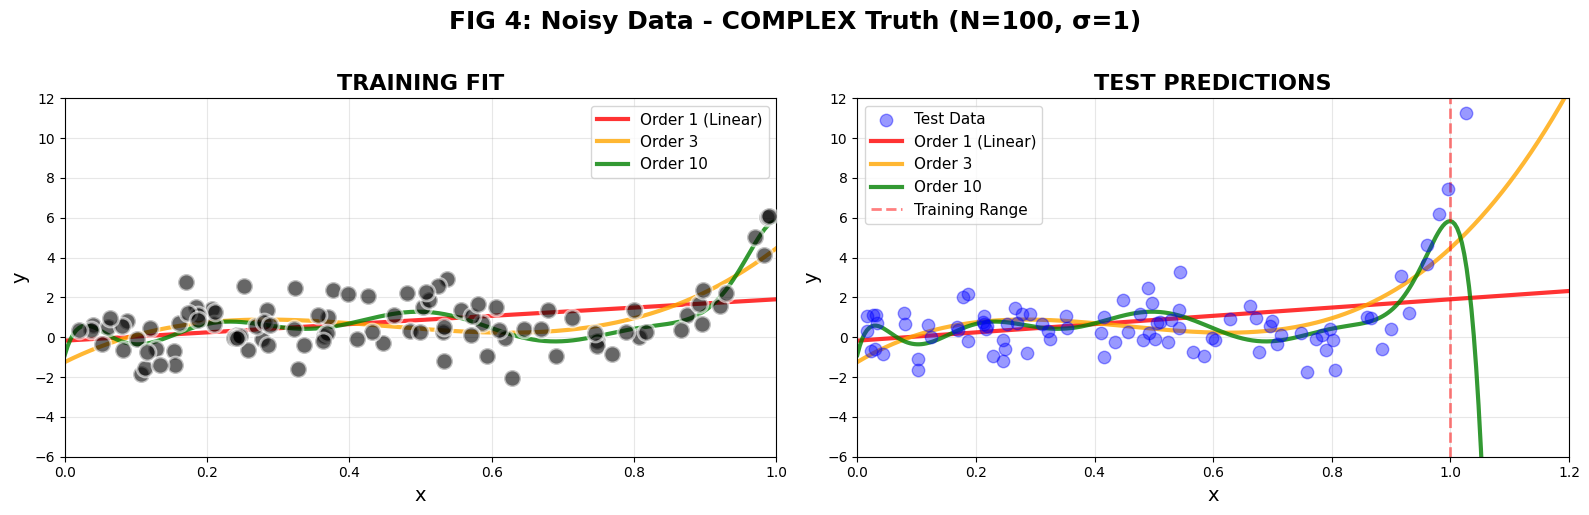

Model                E_train       E_test          Gap
-------------------------------------------------------
Order 1               1.7158     105.4921     103.7763
Order 3               1.2508      68.6283      67.3776
Order 10              0.8956   13613.7283   13612.8327

✓ Best model (lowest E_test): Order 3


In [39]:
# Generate data
x_train, y_train = generate_data(N=100, sigma=1.0, func_type='complex')
x_test, y_test = generate_data(N=100, sigma=1.0, func_type='complex', x_max=1.2)

# Train models
m1, m3, m10, p3, p10 = train_models(x_train, y_train)

# Visualize
plot_comparison(x_train, y_train, x_test, y_test, m1, m3, m10, p3, p10,
               'FIG 4: Noisy Data - COMPLEX Truth (N=100, σ=1)')

# Errors
compute_errors(x_train, y_train, x_test, y_test, m1, m3, m10, p3, p10)

---
## Experiment 5: LARGE Data - COMPLEX TRUTH (M=10,000, σ=1)

**What to observe**: With enough data, Order 10 can handle complexity AND noise.


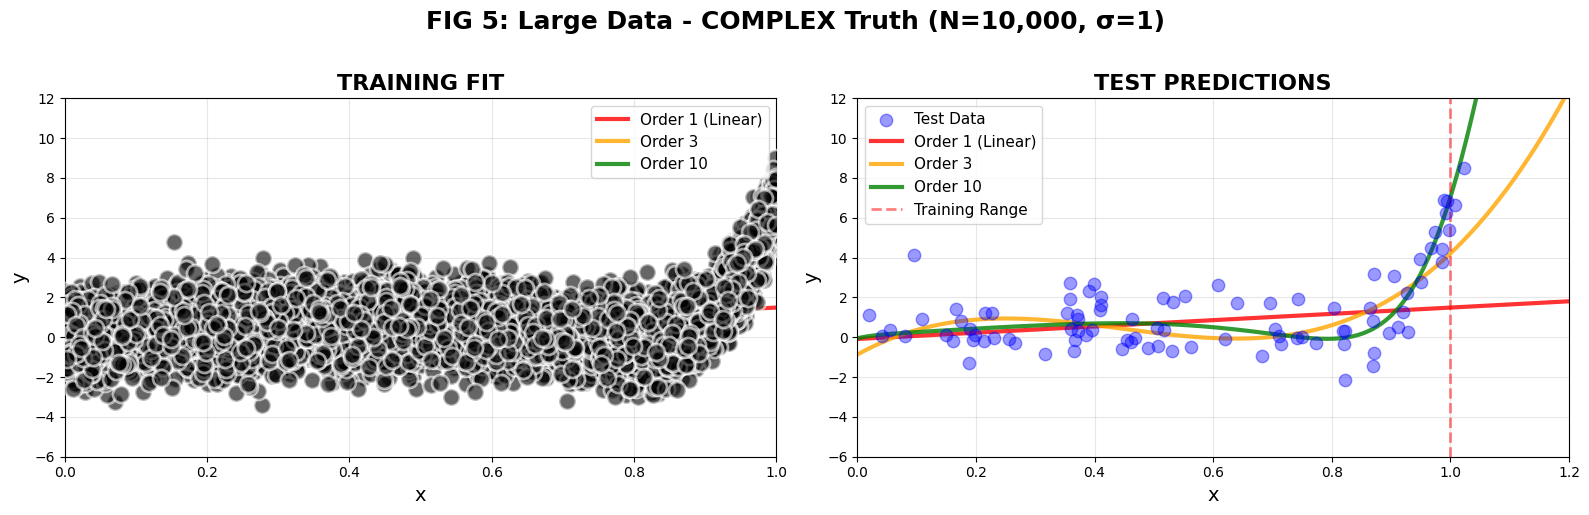


💡 With enough data, complex models can handle noise!

Model                E_train       E_test          Gap
-------------------------------------------------------
Order 1               1.9086     134.6214     132.7128
Order 3               1.3125      88.8057      87.4932
Order 10              0.9887      46.3199      45.3312

✓ Best model (lowest E_test): Order 10


In [40]:
# Generate data
x_train, y_train = generate_data(N=10000, sigma=1.0, func_type='complex')
x_test, y_test = generate_data(N=100, sigma=1.0, func_type='complex', x_max=1.2)

# Train models
m1, m3, m10, p3, p10 = train_models(x_train, y_train)

# Visualize
plot_comparison(x_train, y_train, x_test, y_test, m1, m3, m10, p3, p10,
               'FIG 5: Large Data - COMPLEX Truth (N=10,000, σ=1)')

# Errors
print('\n💡 With enough data, complex models can handle noise!\n')
compute_errors(x_train, y_train, x_test, y_test, m1, m3, m10, p3, p10)

---
## Summary: The Three Laws

### 1. Law of Noise
**Noise punishes complexity**
- High σ → Complex models overfit → Use simpler models
- Low σ → Complex models safe → Can use complexity

### 2. Law of Data
**More data allows more complexity**
- Small sample size M → Simple models generalize better
- Large sample size M → Complex models can be justified

### 3. Law of Truth
**Model class must match problem**
- Simple truth → Simple models win
- Complex truth → Need complex models (but limited by noise and N)

---

## Key Takeaway

**The gap between E_train and E_test reveals overfitting!**

- Small gap + low E_test = Good model ✓
- Large gap = Overfitting (memorizing noise) ✗
- High E_train + high E_test = Underfitting ✗
